# Correlation of POP2 Predictions for Round 2

In [89]:
import pandas as pd
pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_predicted_activity.csv')
# pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_20members_predicted_activity.csv')
pop2_preds = pop2_preds.set_index('seq_id')
model_columns = [c for c in pop2_preds.columns if c.startswith('model_')]

In [92]:
BETA = 0.0
pop2_preds['has_F61'] = pop2_preds.index.str.contains('F61')
pop2_preds['mean'] = pop2_preds[model_columns].mean(axis=1)
pop2_preds['stddev'] = pop2_preds[model_columns].std(axis=1)
pop2_preds['score'] = pop2_preds['mean'] + BETA * pop2_preds['stddev']

pop2_preds = pop2_preds.sort_values('score', ascending=False)

selection_df = pd.concat([
    pop2_preds.head(30),
    pop2_preds[pop2_preds.has_F61].head(30)
])

selection_df

,model_0,model_1,model_2,model_3,model_4,relevant_measured_mutants,has_F61,mean,stddev,score
seq_id,,,,,,,,,,
G429R_R512E,9.460121,18.200731,2.231409,6.024436,11.810726,G429R,False,9.545485,6.040393,9.545485
H8K_G429R,6.126099,14.649279,5.811720,8.401043,11.482740,G429R,False,9.294176,3.755957,9.294176
M320R_G429R,5.902326,13.715607,6.700352,9.042227,11.097433,G429R,False,9.291589,3.205339,9.291589
H8R_G429R,4.590133,13.523048,6.910898,9.201688,11.881597,G429R,False,9.221473,3.618296,9.221473
H8Q_G429R,5.365551,13.385723,5.355792,8.454242,11.144485,G429R,False,8.741159,3.545621,8.741159
Y405R_G429R,5.316650,12.876507,6.004205,8.512884,10.819599,G429R,False,8.705969,3.189244,8.705969
S336R_G429R,4.073412,13.764059,5.639061,7.994379,9.909815,G429R,False,8.276145,3.790866,8.276145
E251R_G429R,3.887148,14.200702,5.022627,7.367267,10.133349,G429R,False,8.122219,4.156496,8.122219
M320G_G429R,3.858293,11.733671,6.492354,8.073214,9.427192,G429R,False,7.916945,2.973835,7.916945


In [93]:
tmp = pop2_preds.reset_index()
tmp[tmp.has_F61]

,seq_id,model_0,model_1,model_2,model_3,model_4,relevant_measured_mutants,has_F61,mean,stddev,score
552,F61L_G429R,0.940150,8.493582,4.314638,7.326700,6.375848,"F61L, G429R",True,5.490184,2.969104,5.490184
663,F61I_G429R,0.821621,9.412415,4.241888,7.080003,5.325764,"F61L, G429R",True,5.376338,3.210427,5.376338
682,F61L_R512E,6.865962,9.913744,0.192278,1.260959,8.570887,F61L,True,5.360766,4.382402,5.360766
759,F61V_G429R,0.684464,8.520223,4.004759,6.827175,6.447108,"F61L, G429R",True,5.296746,3.041329,5.296746
959,F61L_Y405R,2.651900,6.629747,3.491799,5.778980,7.012310,F61L,True,5.112947,1.938861,5.112947
...,...,...,...,...,...,...,...,...,...,...,...
106949,F61L_G181W,-6.067222,-2.648889,-12.413507,-14.775737,-4.359679,F61L,True,-8.053007,5.267769,-8.053007
106955,F61L_C79D,-5.344078,-5.077712,-13.523043,-11.610997,-5.171299,F61L,True,-8.145426,4.093678,-8.145426
106960,F61L_A463C,-4.729659,-4.039878,-12.672201,-12.077190,-7.595319,F61L,True,-8.222849,4.023248,-8.222849
106977,F61L_E361C,-5.824991,-4.021361,-14.863550,-13.808141,-6.267582,F61L,True,-8.957125,4.995595,-8.957125


In [85]:

import plotly.express as px

# Calculate correlation matrix

corr_matrix = selection_df[model_columns].T.corr()

# Create interactive heatmap
fig = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu_r', height=800)
fig.update_layout(title='Covariance Matrix Heatmap')
fig.show()

In [95]:
import json
with open('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_debug_info.json', 'r') as f:
    debug_info = json.load(f)

In [98]:
df = pd.DataFrame()
for model_idx, model in enumerate(debug_info['finetune_metrics']):
    df = pd.concat([
        df,
        pd.DataFrame({
            'model': model_idx,
            'val_loss': model['val_loss'],
            'epoch': range(len(model['val_loss']))
        })
    ])

<Axes: xlabel='epoch', ylabel='val_loss'>

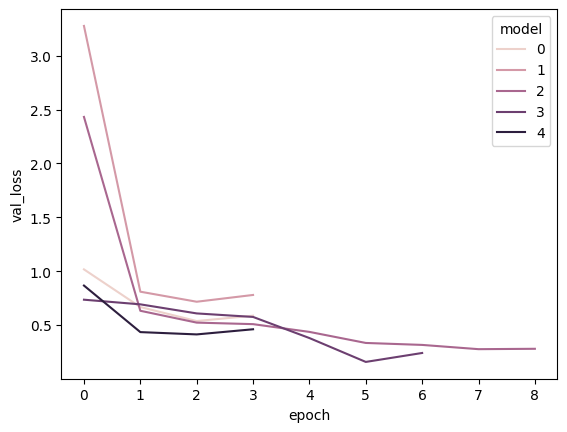

In [101]:
import seaborn as sns
sns.lineplot(
    data=df,
    x='epoch',
    y='val_loss',
    hue='model'
)